<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/MobileNET_Image_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [4]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [5]:
base_dir = '/content/drive/MyDrive/dataset/Augmented'

print(os.listdir(base_dir))
print("Number of classes:", len(os.listdir(base_dir)))

['infected', 'not_infected']
Number of classes: 2


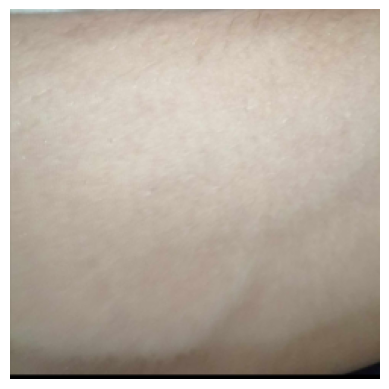

In [7]:
image_path = '/content/364385687_1000397904487356_3154026149160104626_n_augmented_4.png'
img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [8]:
image_path = '/content/364385687_1000397904487356_3154026149160104626_n_augmented_4.png'

# Read the image
img = mpimg.imread(image_path)

print(img)

[[[0.6901961  0.7647059  0.7411765 ]
  [0.72156864 0.8        0.7764706 ]
  [0.72156864 0.8        0.77254903]
  ...
  [0.6509804  0.5686275  0.5019608 ]
  [0.6509804  0.5686275  0.49019608]
  [0.654902   0.5686275  0.4862745 ]]

 [[0.6431373  0.70980394 0.68235296]
  [0.6745098  0.7411765  0.7137255 ]
  [0.6901961  0.7411765  0.7294118 ]
  ...
  [0.6666667  0.5882353  0.52156866]
  [0.67058825 0.5921569  0.5176471 ]
  [0.6627451  0.58431375 0.5058824 ]]

 [[0.6039216  0.63529414 0.60784316]
  [0.627451   0.65882355 0.6313726 ]
  [0.6431373  0.6784314  0.65882355]
  ...
  [0.65882355 0.5921569  0.52156866]
  [0.67058825 0.6039216  0.53333336]
  [0.6666667  0.6        0.5294118 ]]

 ...

 [[0.08627451 0.08235294 0.07058824]
  [0.09019608 0.08235294 0.07058824]
  [0.09019608 0.08235294 0.07058824]
  ...
  [0.01176471 0.01176471 0.01960784]
  [0.00784314 0.01176471 0.01960784]
  [0.01176471 0.01176471 0.01960784]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]


In [9]:
img_size = 224
batch_size = 32
epochs = 10

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


In [11]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


In [12]:
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 7116 images belonging to 2 classes.


In [13]:
validation_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 1778 images belonging to 2 classes.


In [14]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 1948s 8s/step - accuracy: 0.6573 - loss: 0.6688 - val_accuracy: 0.7649 - val_loss: 0.4612
Epoch 2/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 0.8866 - loss: 0.2802 - val_accuracy: 0.7722 - val_loss: 0.4538
Epoch 3/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 566s 3s/step - accuracy: 0.9150 - loss: 0.2168 - val_accuracy: 0.7930 - val_loss: 0.4124
Epoch 4/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 563s 3s/step - accuracy: 0.9236 - loss: 0.1895 - val_accuracy: 0.7868 - val_loss: 0.4430
Epoch 5/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 558s 3s/step - accuracy: 0.9413 - loss: 0.1530 - val_accuracy: 0.7930 - val_loss: 0.4382
Epoch 6/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 558s 3s/step - accuracy: 0.9529 - loss: 0.1324 - val_accuracy: 0.8076 - val_loss: 0.4040
Epoch 7/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - accuracy: 0.9487 - loss: 0.1409 - val_accuracy: 0.8020 - val_loss: 0.4440
Epoch 8/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - accuracy: 0.9531 - loss: 0.1254 - val_acc

In [17]:
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

56/56 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8396 - loss: 0.3852
Validation Accuracy: 83.01%


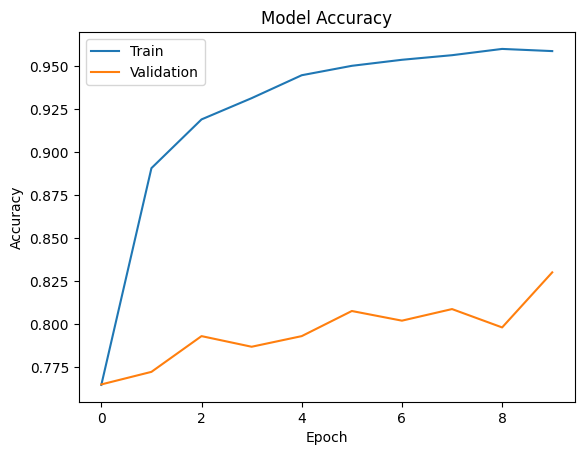

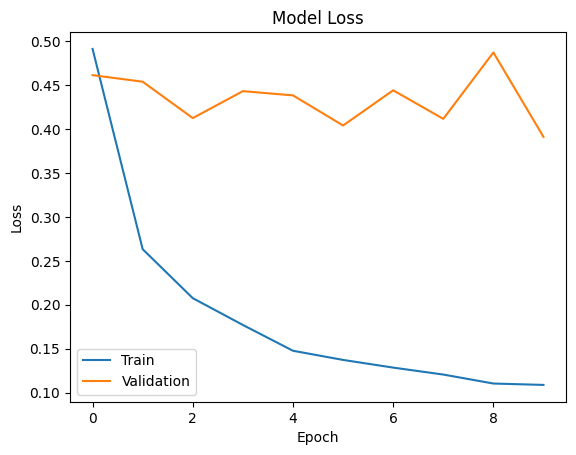

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [21]:
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    return img

def predict_image_class(model, image_path, class_indices):
    img = load_and_preprocess_image(image_path)
    pred = model.predict(img)
    class_id = np.argmax(pred, axis=1)[0]
    return class_indices[class_id]


In [23]:
class_indices = {v: k for k, v in train_generator.class_indices.items()}
json.dump(class_indices, open('class_indices.json', 'w'))

In [24]:
test_image = '/content/IMG_1177_augmented_3.png'
print("Predicted Class:", predict_image_class(model, test_image, class_indices))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: infected
